# Notebook exploratorio para detección de anomalías en Contugas

Este notebook tiene como objetivo responder a la pregunta de negocio planteada para la solución analítica propuesta para Contugas: ¿Qué es una anomalía?

Aquí se utilizan los resultados del modelo entrenado que mejor resultado nos dio:
*  Modelo = Isolation Forest
* Validación Cruzada = 3 splits
* Parámetro Contamination = 0.025

## Librerias

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
from IPython.display import display

## Cargue de resultados

Se carga un archivo tipo xlsx en donde además de las columnas originales de la información entregada por Contugas, se añaden las columnas resultado de la predicción

In [135]:
# Cargar resultados

df = pd.read_excel("resultados_if_completo.xlsx")
print(df.shape)
df.head()

(847960, 47)


,Fecha,Presion,Temperatura,Volumen,Cliente,hour,day_of_week,is_weekend,sin_hour,cos_hour,...,prod_vol_temp,log_presion,log_volumen,log_temperatura,mean_three,std_three,max_three,min_three,is_anomaly,score_if
0,2019-01-14 00:00:00,17.732563,28.209354,20.969751,CLIENTE1,0,0,0,0.000000,1.000000,...,591.543116,2.930263,3.089667,3.374489,22.303889,5.364301,28.209354,17.732563,0,0.076776
1,2019-01-14 01:00:00,17.747776,28.518614,17.845739,CLIENTE1,1,0,0,0.258819,0.965926,...,508.935750,2.931075,2.936287,3.385021,21.370710,6.190461,28.518614,17.747776,0,0.072696
2,2019-01-14 02:00:00,17.758916,28.230191,20.975914,CLIENTE1,2,0,0,0.500000,0.866025,...,592.154045,2.931669,3.089947,3.375202,22.321674,5.363786,28.230191,17.758916,0,0.087201
3,2019-01-14 03:00:00,17.727940,27.811509,20.592299,CLIENTE1,3,0,0,0.707107,0.707107,...,572.702903,2.930017,3.072337,3.360775,22.043916,5.196151,27.811509,17.727940,0,0.091164
4,2019-01-14 04:00:00,17.746484,27.795293,21.690626,CLIENTE1,4,0,0,0.866025,0.500000,...,602.897309,2.931006,3.121952,3.360212,22.410801,5.062967,27.795293,17.746484,0,0.090416


## Análisis Exploratorio de resultados

#### Cantidad de datos y total de anomalías

In [88]:
# Totales globales
N_total      = len(df)
N_anom_total = df['is_anomaly'].sum()
Percentage_anomaly = N_anom_total/N_total*100


print(f'''
    Se cuenta con { N_total} registros, para 20 clientes industriales.
    Se registran { N_anom_total} anomalías, que representan un { Percentage_anomaly}%.
    ''')



    Se cuenta con 847960 registros, para 20 clientes industriales.
    Se registran 21199 anomalías, que representan un 2.5%.
    


Se calculan estadísticas y tasas representativas del conjunto de datos con la predicción, agrupando por cliente

In [89]:
# Agrupación por cliente para ver estadísticas descriptivas
summary = (
    df
    .groupby("Cliente")
    .agg(
        total         = ("is_anomaly", "size"),
        anomalies     = ("is_anomaly", "sum"),
        anomaly_rate  = ("is_anomaly", "mean"),
        avg_temp      = ("Temperatura", "mean"),
        median_temp   = ("Temperatura", "median"),
        avg_pres      = ("Presion", "mean"),
        median_pres   = ("Presion", "median"),
        avg_vol       = ("Volumen", "mean"),
        median_vol    = ("Volumen", "median"),
        avg_score     = ("score_if", "mean"),
        median_score  = ("score_if", "median")
    )
)

# Porcentajes relativos al total
summary['pct_data']      = summary['total']    / N_total
summary['pct_anomalies'] = summary['anomalies'] / N_anom_total

# Tasas y porcentajes como %
summary['anomaly_rate']  = (summary['anomaly_rate'] * 100).round(2).astype(str) + '%'
summary['pct_data']      = (summary['pct_data']     * 100).round(2).astype(str) + '%'
summary['pct_anomalies'] = (summary['pct_anomalies']* 100).round(2).astype(str) + '%'

# Organizar información
order = [f"CLIENTE{i}" for i in range(1, 21)]
summary = summary.reindex(order)

# Resultados
display(summary)

,total,anomalies,anomaly_rate,avg_temp,median_temp,avg_pres,median_pres,avg_vol,median_vol,avg_score,median_score,pct_data,pct_anomalies
Cliente,,,,,,,,,,,,,
CLIENTE1,43412,0,0.0%,25.575853,25.711326,17.535934,17.651439,19.976401,22.470213,0.088561,0.089332,5.12%,0.0%
CLIENTE2,41382,30,0.07%,27.673040,27.493743,17.526440,17.637486,61.819045,61.814487,0.082715,0.086337,4.88%,0.14%
CLIENTE3,42248,7237,17.13%,26.348434,26.345011,3.569593,3.559350,117.500121,125.520304,0.015062,0.015553,4.98%,34.14%
CLIENTE4,42305,5,0.01%,23.241102,23.676157,17.639754,17.779337,17.351570,0.000000,0.073548,0.075936,4.99%,0.02%
CLIENTE5,43415,428,0.99%,23.665282,23.498130,17.489345,17.614668,7.817773,7.119554,0.081030,0.084866,5.12%,2.02%
CLIENTE6,42808,0,0.0%,26.393254,26.366504,17.569108,17.707247,153.799976,198.223662,0.084123,0.087311,5.05%,0.0%
CLIENTE7,41776,1449,3.47%,23.622548,24.074797,17.490812,17.493758,27.294379,0.000000,0.086531,0.093650,4.93%,6.84%
CLIENTE8,43147,1366,3.17%,26.814551,26.896418,16.705630,16.567409,178.591825,221.111139,0.039458,0.034976,5.09%,6.44%
CLIENTE9,42428,0,0.0%,22.073596,22.247295,17.466627,17.497293,12.734989,0.000000,0.087452,0.087972,5.0%,0.0%


/var/folders/zl/j_t91wbj7px3m0954fvcj8kw0000gn/T/ipykernel_82987/3276747901.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


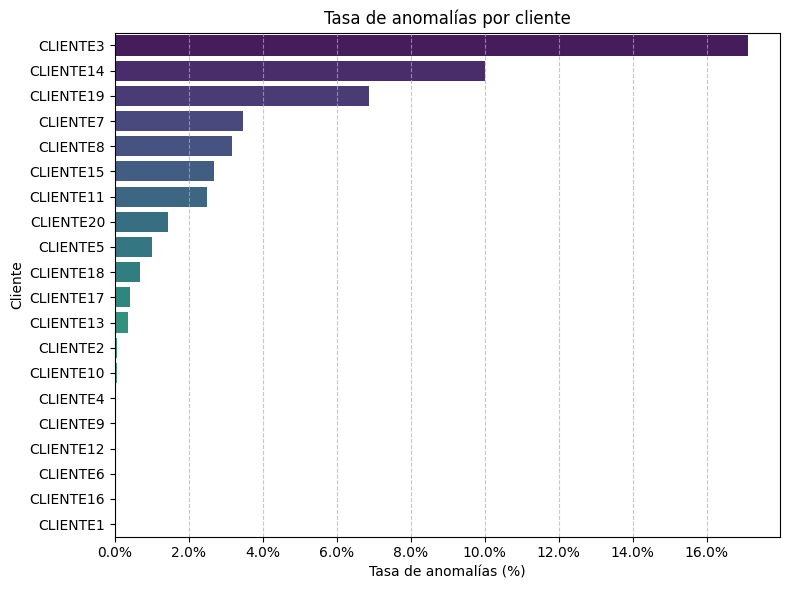

In [ ]:
# Tasa de anomalías por cliente

summary_raw = summary.copy()
# Convertir a decimales los porcentajer
summary_raw['anomaly_rate'] = summary_raw['anomaly_rate'].str.rstrip('%').astype(float) / 100
summary_raw['pct_anomalies'] = summary_raw['pct_anomalies'].str.rstrip('%').astype(float) / 100

# Prepara df_plot y reinicia el índice para usar nombres de columna
df_plot = summary_raw.sort_values('anomaly_rate', ascending=False).reset_index()

# Tasa de anomalías por cliente
plt.figure(figsize=(8, 6))
ax1 = sns.barplot(
    data=df_plot,
    x='anomaly_rate',
    y='Cliente',
    palette='viridis'
)
ax1.set_xlabel("Tasa de anomalías (%)")
ax1.set_ylabel("Cliente")
ax1.set_title("Tasa de anomalías por cliente")
ax1.xaxis.set_major_formatter(lambda x, pos: f"{x*100:.1f}%")
ax1.grid(axis='x', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

/var/folders/zl/j_t91wbj7px3m0954fvcj8kw0000gn/T/ipykernel_82987/4196686916.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(


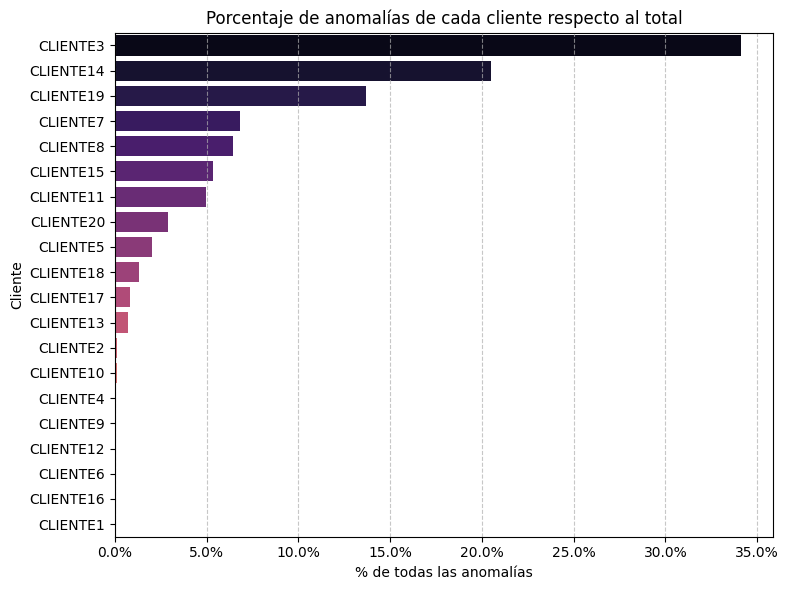

In [91]:
# % de anomalías de cada cliente respecto al total
plt.figure(figsize=(8, 6))
ax2 = sns.barplot(
    data=df_plot,
    x='pct_anomalies',
    y='Cliente',
    palette='magma'
)
ax2.set_xlabel("% de todas las anomalías")
ax2.set_ylabel("Cliente")
ax2.set_title("Porcentaje de anomalías de cada cliente respecto al total")
ax2.xaxis.set_major_formatter(lambda x, pos: f"{x*100:.1f}%")
ax2.grid(axis='x', linestyle='--', alpha=0.7)  # añade cuadrícula horizontal
plt.tight_layout()
plt.show()

De las dos gráficas anteriores y de la tabla de estadística se puede observar:
* De 20 clientes industriales, 14 clientes registran anomalías, mientras que 6 clientes no registran anomalías en su consumo. 
* Al observar la proporción de anomalías que representa cada cliente respecto al total de anomalías de toda la muestra:
    * Los clientes que más anomalías registran son los clientes 3, 14 y 19 con una representación del: 34.14%, 20.47% y 13.7%, respectivamente.
        * Los clientes 3 y 14, representan el 54,61% de todas las anomalías.
        * Lo clientes 3, 14 y 19, representan el 68.37% de todas las anomalías
    * Esto sugiere que las anomlías se concentran principalmente en algunos clientes.
    * El otro 31.69% de anomalías se distribuye entre 11 clientes, en un rango del 6.48% al 0.12%.
    * Los cliente 4 y 12, presentan muy pocas anomalías.
    * Los clientes 1, 6, 9 y 16, no presentan anomalías.

### Gráficas de caja para variables relevantes

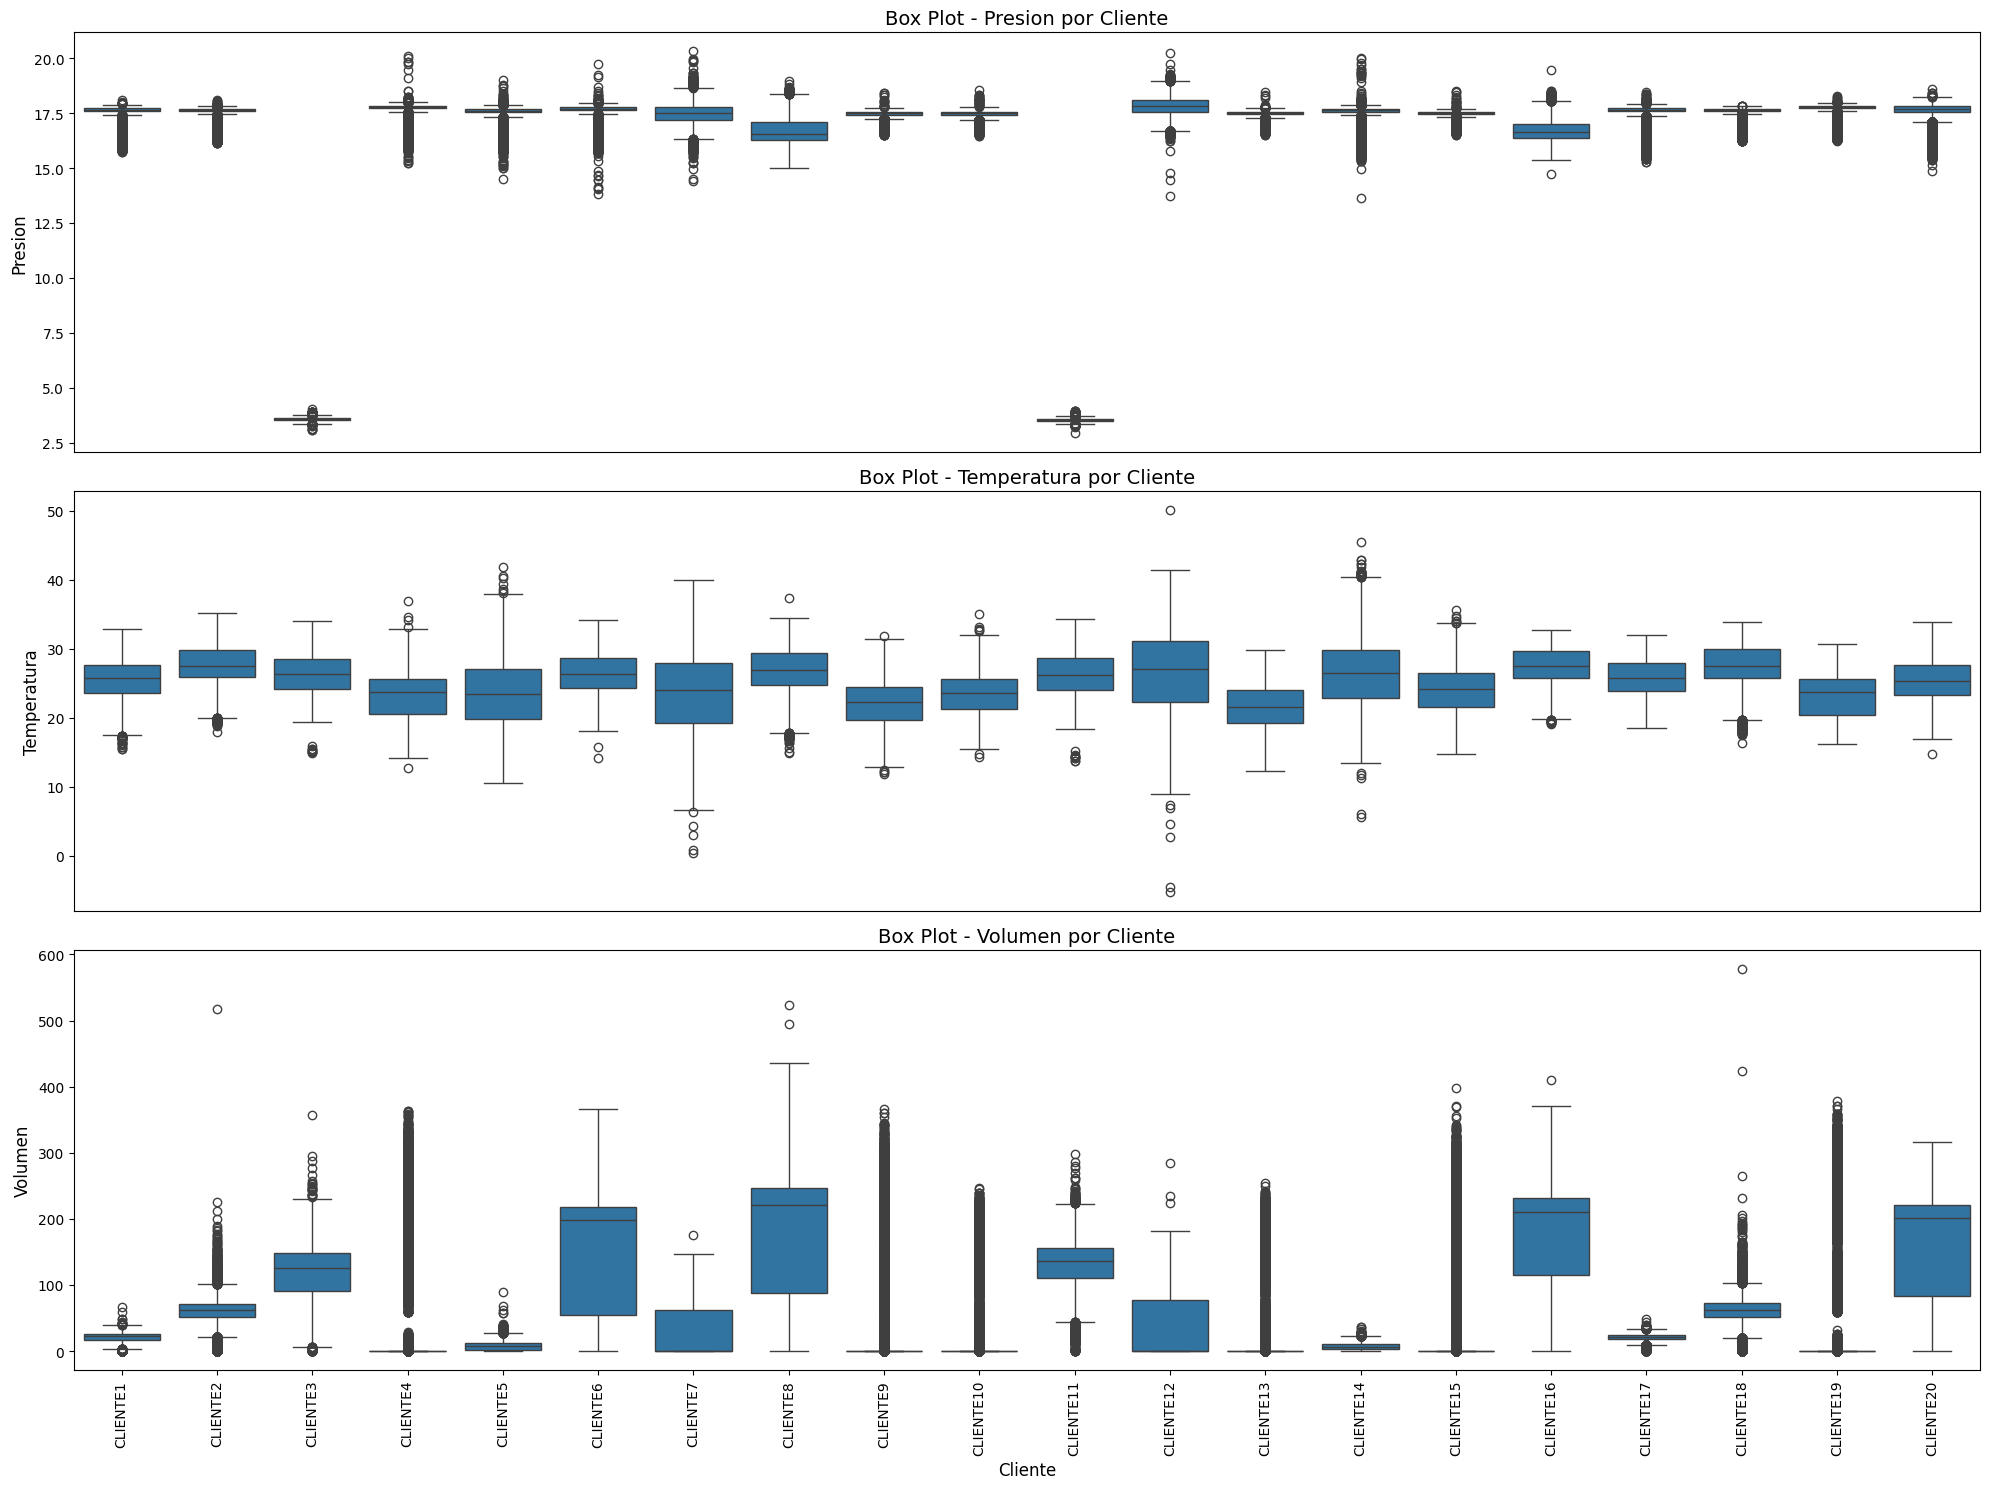

In [ ]:
# Variables a graficar
vars_to_plot = ['Presion', 'Temperatura', 'Volumen']

# Configuración de la figura: 4 filas x 1 columna
fig, axes = plt.subplots(nrows=len(vars_to_plot), ncols=1, 
                         figsize=(20, 5 * len(vars_to_plot)), 
                         sharex=True)

for ax, var in zip(axes, vars_to_plot):
    sns.boxplot(data=df, x='Cliente', y=var, ax=ax)
    ax.set_title(f'Box Plot - {var} por Cliente', fontsize=14)
    ax.set_xlabel('')  # solo mostramos etiqueta en el último subplot
    ax.set_ylabel(var, fontsize=12)
    # rotar etiquetas solo en la parte de abajo
    if var == vars_to_plot[-1]:
        ax.set_xlabel('Cliente', fontsize=12)
        ax.tick_params(axis='x', rotation=90)
    else:
        ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

plt.tight_layout()
plt.show()

* El cliente 3 se caracteriza por tener presiones bajas, al igual que el cliente 11. No obstante y como se observo previamente el cliente 3, es el que más anomalías registra, el cliente 11, presenta anomalías pero no en igual proporción.
* Los clientes 14 y 19, se caracterizan por tener volumenes, sin embargo, otro clientes también tuvieron esos volumenes bajos.

### Correlaciones

Se busca encontrar correlación entre las variables originales y las creadas para ejecutar el modelo. Solamente para el grupo de anomalías

,Presion,Temperatura,Volumen,hour,day_of_week,is_weekend,sin_hour,cos_hour,sin_day_of_week,cos_day_of_week,...,prod_vol_temp,log_presion,log_volumen,log_temperatura,mean_three,std_three,max_three,min_three,is_anomaly,score_if
Presion,1.000000,-0.011566,-0.590549,0.076340,-0.061363,-0.098408,-0.085497,-0.057331,0.118845,0.003947,...,0.380746,0.511061,0.254560,0.168964,0.372419,0.336129,0.348695,0.501695,NaN,-0.051579
Temperatura,-0.011566,1.000000,0.108227,0.010934,0.070939,0.062402,-0.002840,-0.006652,-0.054207,0.019015,...,0.184067,-0.071341,-0.075980,0.613999,-0.019723,-0.065425,-0.052048,-0.075280,NaN,0.088105
Volumen,-0.590549,0.108227,1.000000,0.008289,0.034353,0.043388,0.013528,-0.006163,-0.048980,-0.061337,...,-0.064371,-0.120141,0.028716,-0.056949,-0.043210,-0.027790,-0.032528,-0.116432,NaN,-0.032934
hour,0.076340,0.010934,0.008289,1.000000,-0.059734,-0.083790,-0.717266,-0.166278,0.081140,-0.059245,...,0.244275,0.224281,0.224473,0.085200,0.246108,0.240391,0.242525,0.222703,NaN,-0.101460
day_of_week,-0.061363,0.070939,0.034353,-0.059734,1.000000,0.863974,0.087904,-0.071764,-0.783534,-0.165644,...,-0.162942,-0.150639,-0.225312,0.083293,-0.214747,-0.228991,-0.224487,-0.152999,NaN,-0.005278
is_weekend,-0.098408,0.062402,0.043388,-0.083790,0.863974,1.000000,0.110975,-0.063574,-0.857606,0.165308,...,-0.239848,-0.224396,-0.295624,0.060655,-0.296588,-0.309707,-0.305454,-0.226474,NaN,0.024957
sin_hour,-0.085497,-0.002840,0.013528,-0.717266,0.087904,0.110975,1.000000,0.019550,-0.105719,0.052258,...,-0.216006,-0.194758,-0.183010,-0.095772,-0.207211,-0.199535,-0.202318,-0.192546,NaN,0.117755
cos_hour,-0.057331,-0.006652,-0.006163,-0.166278,-0.071764,-0.063574,0.019550,1.000000,0.075043,0.019174,...,-0.108100,-0.138391,-0.088304,-0.055884,-0.110303,-0.101018,-0.104241,-0.137380,NaN,-0.041205
sin_day_of_week,0.118845,-0.054207,-0.048980,0.081140,-0.783534,-0.857606,-0.105719,0.075043,1.000000,-0.019006,...,0.232853,0.246923,0.276388,-0.059509,0.292265,0.301730,0.298610,0.248537,NaN,-0.024098
cos_day_of_week,0.003947,0.019015,-0.061337,-0.059245,-0.165644,0.165308,0.052258,0.019174,-0.019006,1.000000,...,-0.192995,-0.155020,-0.211112,-0.033885,-0.205996,-0.208642,-0.208107,-0.155067,NaN,0.075507


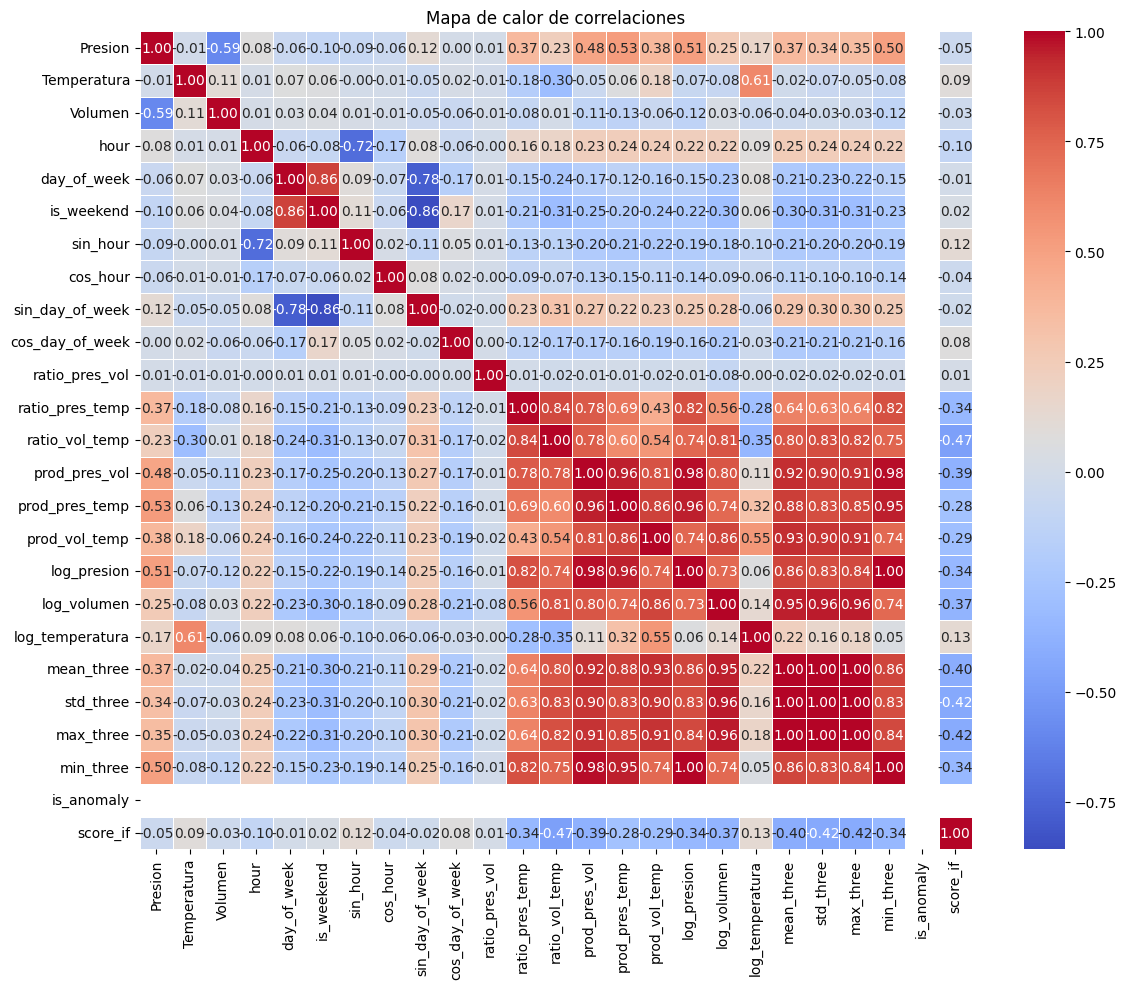

In [97]:
# Columnas numéricas

anom = df[df['is_anomaly'] == 1].copy()
num_df = anom.select_dtypes(include='number')

# Correlaciones
corr_matrix = num_df.corr()


display(corr_matrix)


# 4) Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Mapa de calor de correlaciones")
plt.tight_layout()
plt.show()

Correlación para el grupo de anomalías:
* Hay una correlación moderada negativa entre el Volumen y la presión, indicando que cuando se presentan grandes demandas ocurren bajones de presión.
* La temperatura, ni el tiempo son factores determinantes para que suceda una anomalía.

#### Anomalías para los 3 clientes principales

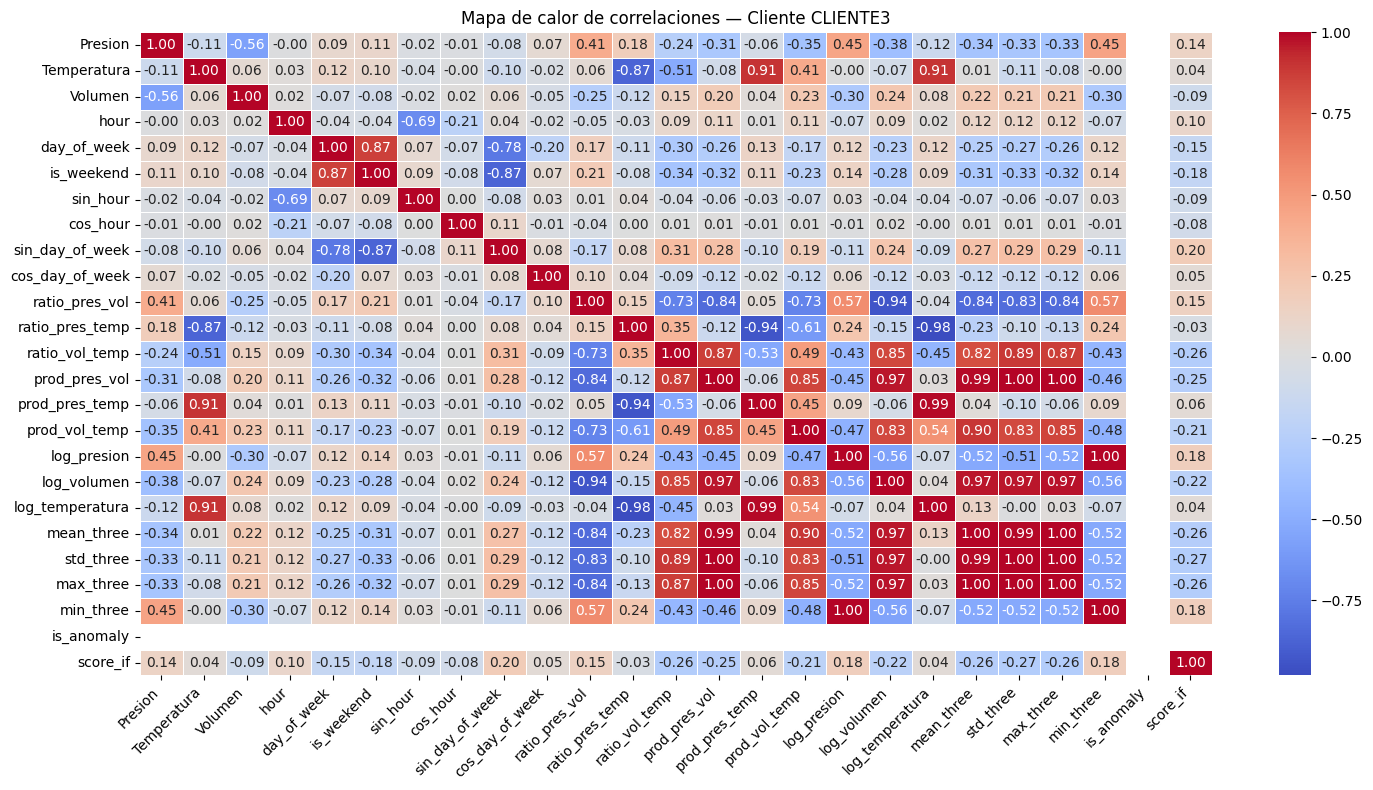

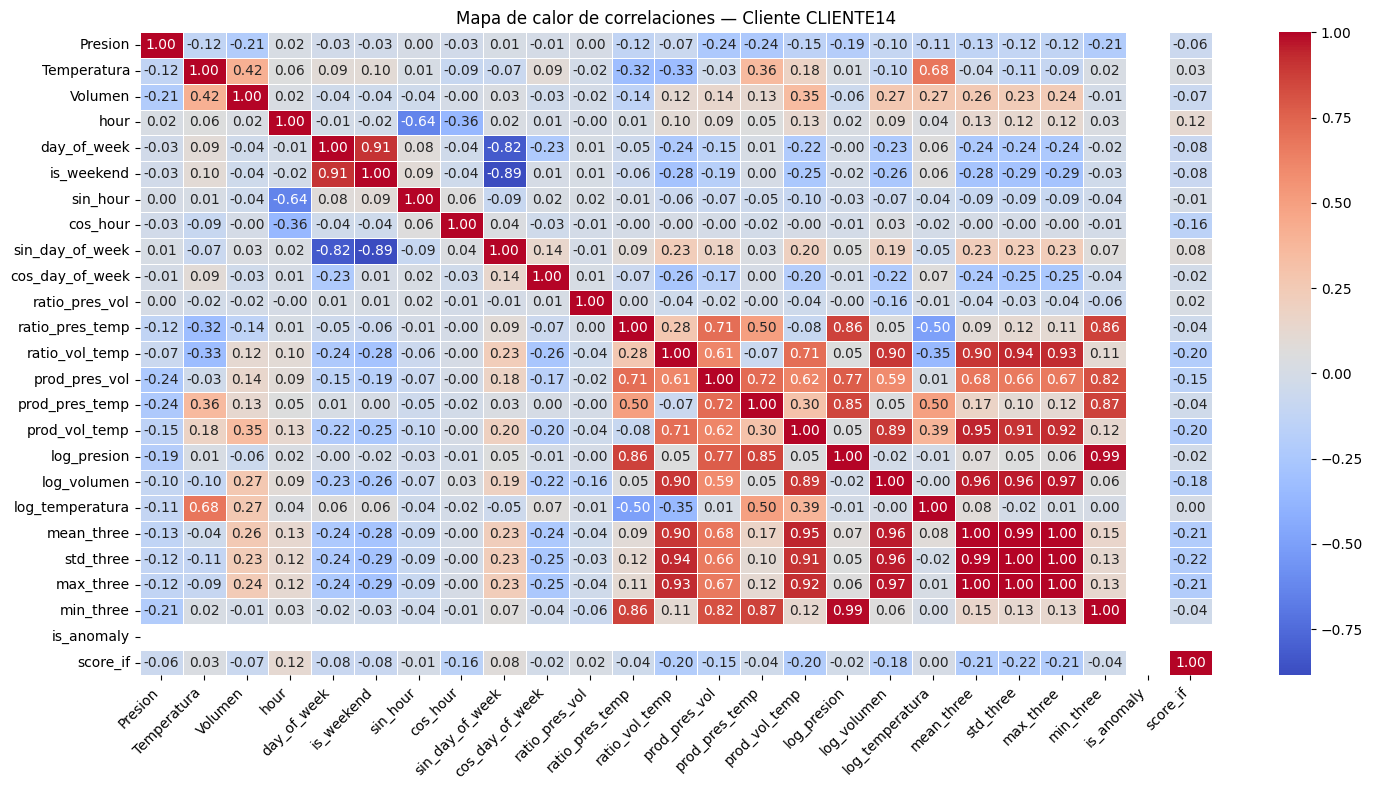

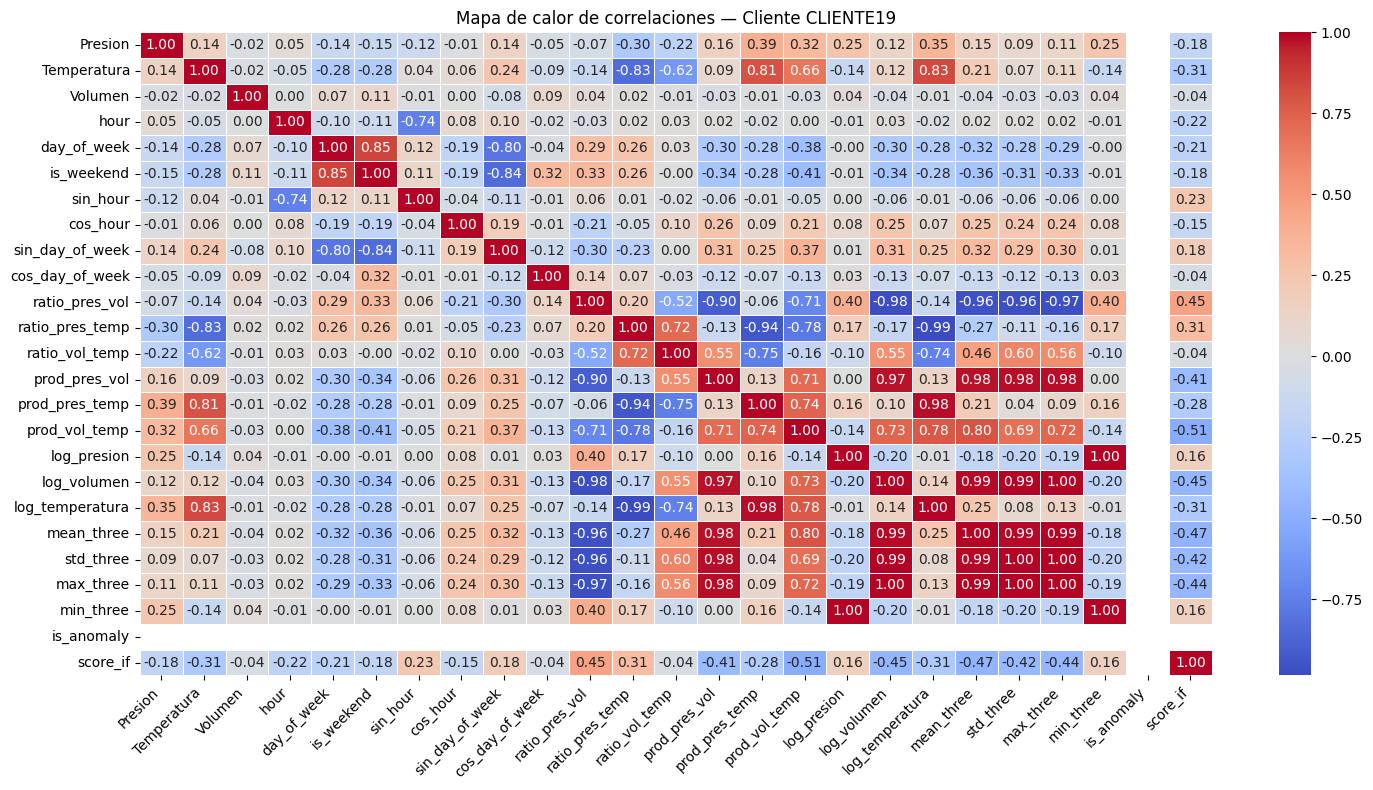

In [103]:
# Para los clientes con más anomalías

top_clients = (
    anom['Cliente']
    .value_counts()
    .nlargest(3)
    .index
    .tolist()
)

# Para cada uno, calcula y dibuja su matriz de correlación
for cli in top_clients:
    sub = anom[anom['Cliente'] == cli]
    num_df = sub.select_dtypes(include='number')
    
    # Si no hay suficientes datos, saltar
    if num_df.shape[0] < 2:
        print(f"Cliente {cli}: datos insuficientes para correlación.")
        continue
    
    corr_matrix = num_df.corr()
    
    plt.figure(figsize=(15, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        linewidths=0.5,
        cbar=True
    )
    plt.title(f"Mapa de calor de correlaciones — Cliente {cli}")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

Con base en los mapas de calor de correlación para las anomalías del 3 clientes que más anomalías presentan, se comprende:
* Cliente 3:
    * Se están detectando como anomalía el patrón físico en que el usuario al extraer más gas, la presión cae por debajo de lo normal. 
    * La temperatura, ni el tiempo, no son factores decisivos.
* Cliente 14:
    * Dentro del grupo de anomalías existe una correlación entre el volumen y temperatura, a mayor flujo, aumenta la temperatura. 
    * Hay una alta correlación entre en la presencia de anomalías los fines de semana. 
    * La presión no es factor determinante en las anomalías.
* Cliente 19:
    *	Los picos de temperatura son clave: anomalías muy altas positivamente (log_temperatura) aparecen junto a valores altos de producto presión–temperatura.
	•	El score_if se dispara (score bajo) cuando se combinan volumen alto y temperatura alta (prod_vol_temp), más que por la presión en sí.
	•	A diferencia de otros clientes, no hay una relación clara entre presión y volumen dentro de sus anomalías; aquí el modelo está capturando eventos de sobrecalentamiento con alto flujo, más que caídas de presión.


### Gráficas de anomalías vs los registros de variables dadas a lo largo del tiempo

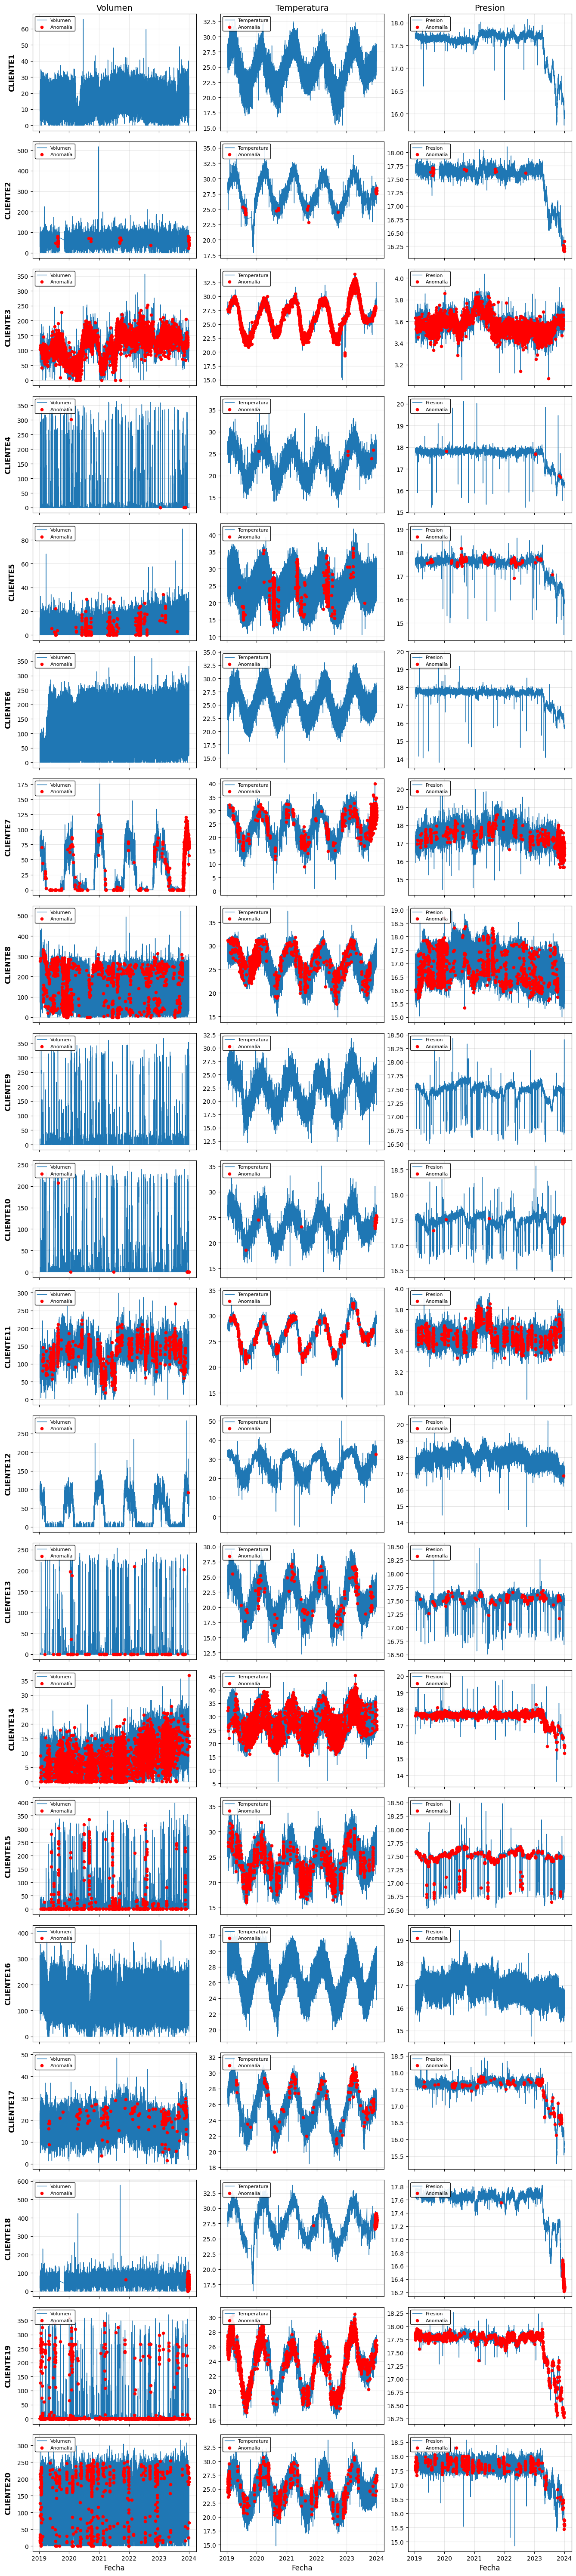

In [17]:
import matplotlib.pyplot as plt

clientes  = df['Cliente'].unique()
variables = ['Volumen', 'Temperatura', 'Presion']

fig, axes = plt.subplots(
    nrows=len(clientes),
    ncols=len(variables),
    figsize=(15, len(clientes) * 3),
    sharex=True
)

for i, cliente in enumerate(clientes):
    cliente_data = df[df['Cliente'] == cliente]
    
    # Ponemos el nombre del cliente verticalmente al lado izquierdo de cada fila
    axes[i, 0].set_ylabel(
        cliente,
        rotation=90,
        labelpad=15,
        va='center',
        fontsize=12,
        fontweight='bold'
    )
    
    for j, var in enumerate(variables):
        ax = axes[i, j]
        
        # Serie continua de la variable física
        ax.plot(
            cliente_data['Fecha'], cliente_data[var],
            color='C0', lw=1, label=var
        )
        
        # Puntos rojos sobre anomalías
        anoms = cliente_data[cliente_data['is_anomaly'] == 1]
        ax.scatter(
            anoms['Fecha'], anoms[var],
            color='red', s=20, marker='o',
            label='Anomalía', zorder=5
        )
        
        # Título de cada columna (solo en la primera fila)
        if i == 0:
            ax.set_title(var, fontsize=14)
        
        # Etiqueta X solo en la última fila
        if i == len(clientes) - 1:
            ax.set_xlabel('Fecha', fontsize=12)
        
        # Agregar recuadro alrededor de la leyenda
        legend = ax.legend(loc='upper left', fontsize=8, frameon=True, 
                           framealpha=0.9, edgecolor='black')
        
        ax.grid(alpha=0.3)

plt.tight_layout(rect=[0.1, 0, 1, 1])  # reserva espacio izquierdo para ylabels
plt.show()

* De estás gráficas se puede identficar que para ningún cliente hay algún patrón claro de presencia de anomalías, de caracter visual. 
* Aquí se pudo verificar que el modelo si identifica los datos en 0 o los periodos sin información como una posible anomalía, razón por la que incluímos estos datos en el modelo. Dentro de la información disponible, no conocemos si durante estos periodos hubo una falla en el sistema o en el equipo de medición. Por lo que es necesario corroborar este información y asociarla a estos eventos, para mejorar la predicción.

### Cada cuanto se presentan las anomalías

In [125]:
# Cada cuanto ocurre una anomalía?

# Asegura datetime y ordena
df['Fecha'] = pd.to_datetime(df['Fecha'])
df = df.sort_values(['Cliente','Fecha'])

# Calcula diferencias de tiempo
anoms = df[df['is_anomaly']==1].copy()
anoms['diff_hours'] = anoms.groupby('Cliente')['Fecha'].diff().dt.total_seconds() / 3600

# Convierte a días y meses (suponiendo 30 días por mes)
anoms['diff_days']   = anoms['diff_hours']   / 24
anoms['diff_months'] = anoms['diff_days']    / 30

# Agrega estadísticas por cliente
summary_intervals = anoms.groupby('Cliente').agg(
    count_anoms   = ('diff_hours',  'count'),
    mean_hours    = ('diff_hours',  'mean'),
    median_hours  = ('diff_hours',  'median'),
    mean_days     = ('diff_days',   'mean'),
    median_days   = ('diff_days',   'median'),
    mean_months   = ('diff_months', 'mean'),
    median_months = ('diff_months', 'median'),
).reset_index()


#  Ordena de mayor a menor por número de anomalías
summary_intervals = summary_intervals.sort_values(
    by='count_anoms',
    ascending=False
).reset_index(drop=True)

# 7) Muestra la tabla
display(summary_intervals)

,Cliente,count_anoms,mean_hours,median_hours,mean_days,median_days,mean_months,median_months
0,CLIENTE3,7236,5.963516,1.0,0.248480,0.041667,0.008283,0.001389
1,CLIENTE14,4339,10.018437,1.0,0.417435,0.041667,0.013914,0.001389
2,CLIENTE19,2904,14.967287,1.0,0.623637,0.041667,0.020788,0.001389
3,CLIENTE7,1448,29.679558,1.0,1.236648,0.041667,0.041222,0.001389
4,CLIENTE8,1365,30.416117,2.0,1.267338,0.083333,0.042245,0.002778
5,CLIENTE15,1138,37.273286,1.0,1.553054,0.041667,0.051768,0.001389
6,CLIENTE11,1049,39.725453,1.0,1.655227,0.041667,0.055174,0.001389
7,CLIENTE20,616,70.629870,2.0,2.942911,0.083333,0.098097,0.002778
8,CLIENTE5,427,85.768150,1.0,3.573673,0.041667,0.119122,0.001389
9,CLIENTE18,282,65.507092,1.0,2.729462,0.041667,0.090982,0.001389


              Presion                                                       \
                 mean     median       std       min        max   quantile   
is_anomaly                                                                   
0           16.177253  17.572354  4.044542  2.934873  20.307852  17.572354   
1           12.005404  16.926367  6.789613  3.073193  18.704900  16.926367   

           Temperatura                                                       \
                  mean     median       std       min        max   quantile   
is_anomaly                                                                    
0            25.192670  25.381502  3.789484 -5.257899  50.019853  25.381502   
1            25.415427  25.290932  3.823556  9.011817  45.378176  25.290932   

              Volumen                                                    
                 mean     median        std  min         max   quantile  
is_anomaly                                                       

/var/folders/zl/j_t91wbj7px3m0954fvcj8kw0000gn/T/ipykernel_82987/1294848190.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="is_anomaly", y=var, data=df, inner="quartile", palette=["#2a9d8f", "#e76f51"])  # 0 → verde, 1 → rojo


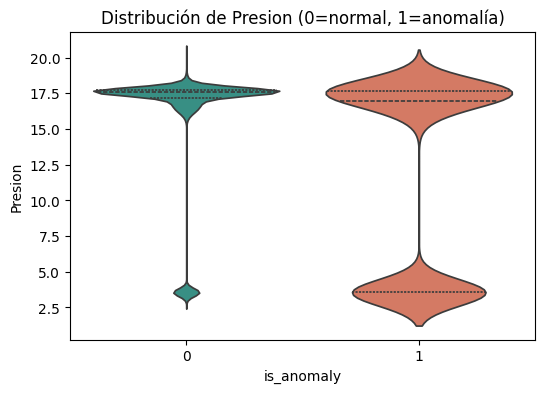

/var/folders/zl/j_t91wbj7px3m0954fvcj8kw0000gn/T/ipykernel_82987/1294848190.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="is_anomaly", y=var, data=df, inner="quartile", palette=["#2a9d8f", "#e76f51"])  # 0 → verde, 1 → rojo


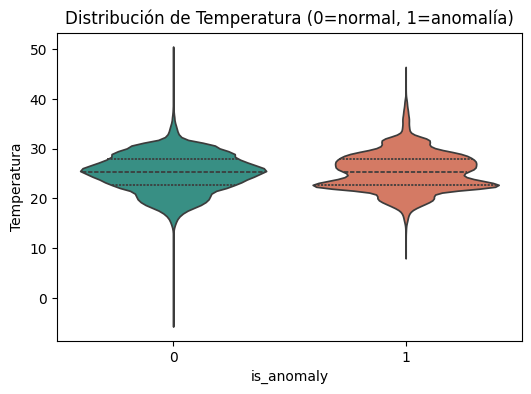

/var/folders/zl/j_t91wbj7px3m0954fvcj8kw0000gn/T/ipykernel_82987/1294848190.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="is_anomaly", y=var, data=df, inner="quartile", palette=["#2a9d8f", "#e76f51"])  # 0 → verde, 1 → rojo


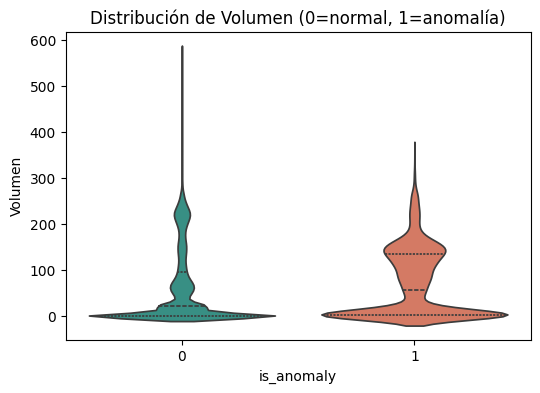

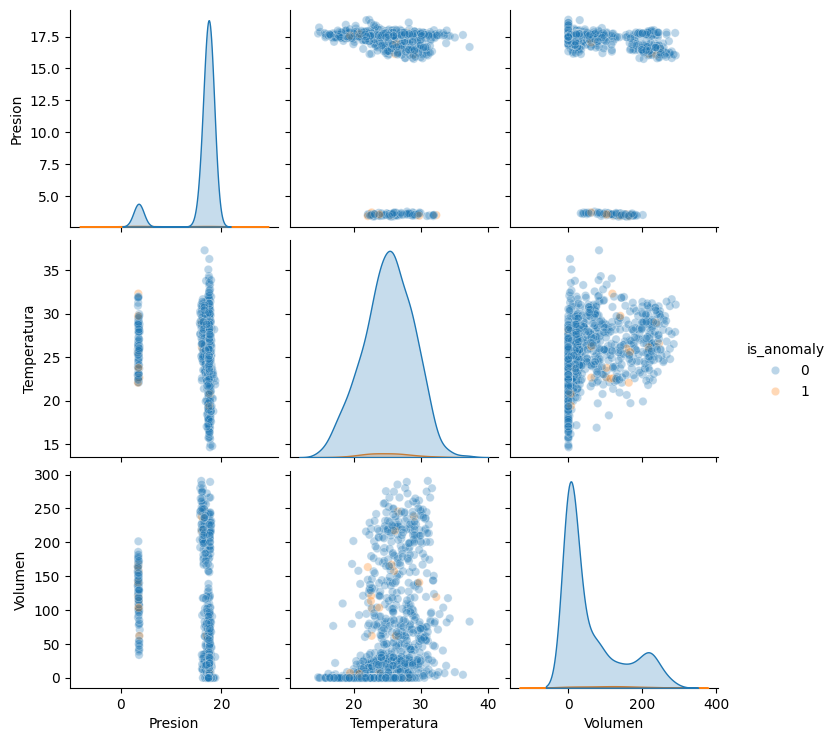

In [123]:
# Asume df_final con X_full + is_anomaly
import pandas as pd

# 1. Estadísticas descriptivas
descr = (
    df
    .groupby("is_anomaly")[["Presion","Temperatura","Volumen"]]
    .agg(["mean","median","std","min","max","quantile"])
)
print(descr)

# 2. Violin plots por variable
import seaborn as sns
import matplotlib.pyplot as plt

for var in ["Presion","Temperatura","Volumen"]:
    plt.figure(figsize=(6,4))
    sns.violinplot(x="is_anomaly", y=var, data=df, inner="quartile", palette=["#2a9d8f", "#e76f51"])  # 0 → verde, 1 → rojo
    plt.title(f"Distribución de {var} (0=normal, 1=anomalía)")
    plt.show()

# 3. Pairplot coloreado
sns.pairplot(df.sample(1000), 
             vars=["Presion","Temperatura","Volumen"], 
             hue="is_anomaly", 
             plot_kws={"alpha":0.3})
plt.show()

Análisis de gráficas de violín para la presión, temperatura y volumen:
* Presión:
    * La presión de operación típica se concentra entre los 17 y 18 bar,  la mayoría de registros suceden al rededor de estos valores con poca variabilidad, para las medidas que no se concideran anomalías.
    * Para el grupo de anomalías se presentan dos colas:
        * Al rededor de los 3 y los 5 bar, indicando que sobre esas bajas de presión el modelo comienza asociar anomalía. 
        * La segunda está alrededor de los 15 a 19 bar, estando un poco por encima de los registros no anomalos, lo que indica que un pico alto de presión también puede llegar a ser considerado como una anomalía.
    * Las anomalías para presión se concentran para picos altos y bajos de presión.
* Temperatura:
    * Para los registros no anomalos, los datos se concentran alrededor de los 20 y 28 °C. 
    * Los registros anomalos presentan un rango un poco superior en temperatura, concentrandose un poco más cerca a los 30 °C. 
    * Las variaciones muy sutiles respecto a los dos grupos, por lo que la temperatura puede ser un factor no decisivo en la detección de una anomalía, como lo corrobora también la correlación entre variables.
* Volumen:
    * Para los registros no anomalos, muestra una cintura amplia en valores cercanos a cero, y tiene picos que no se marcan como anomalías.
    * En los registros anomalos, se puede observar que el violin se agranda hacia valores entre los 100 y 150 m3. Relacionando estos valores intermedio como anomalías.

/var/folders/zl/j_t91wbj7px3m0954fvcj8kw0000gn/T/ipykernel_82987/1545207186.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/zl/j_t91wbj7px3m0954fvcj8kw0000gn/T/ipykernel_82987/1545207186.py:21: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.violinplot(
/var/folders/zl/j_t91wbj7px3m0954fvcj8kw0000gn/T/ipykernel_82987/1545207186.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/zl/j_t91wbj7px3m0954fvcj8kw0000gn/T/ipykernel_82987/1545207186.py:21: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.violinplot(
/var/folders/zl/j_t91wbj7px3m0954fvcj8kw00

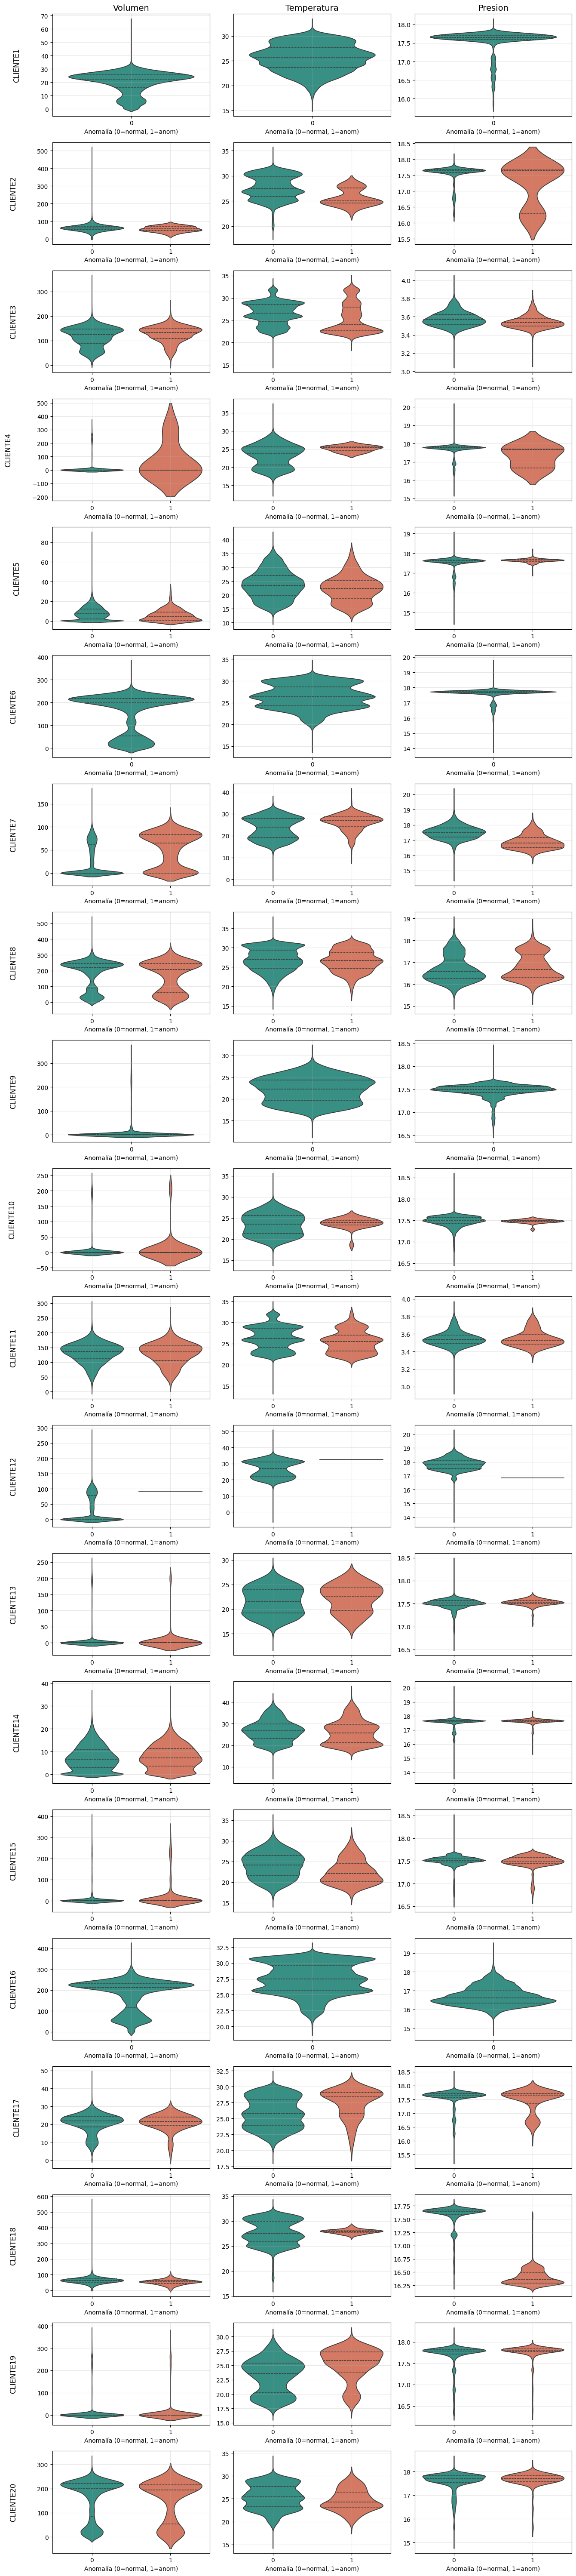

In [136]:
import seaborn as sns
import matplotlib.pyplot as plt

variables = ['Volumen', 'Temperatura', 'Presion']
clientes  = df['Cliente'].unique()

fig, axes = plt.subplots(
    nrows=len(clientes),
    ncols=len(variables),
    figsize=(15, 3 * len(clientes)),
    sharex=False,
    sharey=False
)

for i, cliente in enumerate(clientes):
    sub = df[df['Cliente'] == cliente]
    
    for j, var in enumerate(variables):
        ax = axes[i, j] if len(clientes) > 1 else axes[j]
        
        sns.violinplot(
            x='is_anomaly',
            y=var,
            data=sub,
            ax=ax,
            inner='quartile',
            palette=["#2a9d8f", "#e76f51"]  # 0 → verde, 1 → rojo
        )
        
        # Títulos y etiquetas
        if i == 0:
            ax.set_title(var, fontsize=14)
        if j == 0:
            ax.set_ylabel(
                cliente,
                fontsize=12,
                rotation=90,
                labelpad=40,
                va='center'
            )
        else:
            ax.set_ylabel('')
        
        ax.set_xlabel('Anomalía (0=normal, 1=anom)', fontsize=10)
        ax.grid(alpha=0.3)
        
plt.tight_layout(rect=[0.1, 0, 1, 1])
plt.show()

Lectura por cliente:
* Cliente 1: no presenta anomalías.
* Cliente 2: el modelo considera anómalos los consumos de volumen intermedio (40–70 m³) —aunque maneje picos mayores— cuando van acompañados de temperaturas moderadas (24–28 °C) y de presión fuera de su banda ultra‐estrecha (caídas a 16 –16.5 bar o picos a 17.8–18.2 bar); esos rangos específicos, que difieren tanto de sus valores normales más bajos o de sus picos extremos, son los que disparan la detección de anomalías. Siendo muy claro visualmente que los cambios de presión fuera de lo habitual, marcan con más tendencia las anomalías.
* Cliente 3: lo que más afecta en la detección es la caída de presión: cuando baja de sus 3,5 – 3,7 bar habituales, el modelo marca anomalía. El volumen y la temperatura cambian un poco (más flujo y temperaturas algo menores), pero es ese bache en la presión el que realmente dispara la detección.
* Cliente 4: el detonante principal de anomalías son los picos bruscos de volumen: mientras que en lo normal el caudal ronda siempre por debajo de 10 m³, el modelo marca como atípicos los saltos repentinos hasta 200–300 m³. La presión y la temperatura varían algo en esos instantes (caídas y subidas ligeras), pero es esa subida súbita de volumen la que “enciende” la alarma.
* Cliente 5: Las anomalías se detectan cuando la temperatura cae bruscamente por debajo de su rango normal (de ~20 °C hasta ~15 °C), incluso con volúmenes muy bajos (< 10 m³) y presión casi constante. Aunque no es realmente un patrín sencillo de identificar.
* Cliente 6: no registra anomalías. 
* Cliente 7: Las anomalías se disparan principalmente cuando la presión baja de su rango normal (de 17.3–17.6 bar aproximadamente) hasta unos 16.5–17.0 bar; el volumen y la temperatura solo acompañan (volumen medio-alto, 70–90 m³, y temperatura estable en 24–26 °C), pero es esa caída de presión la que realmente marca el evento atípico.
* Cliente 8:aquí el modelo detecta anomalías sobre todo en volúmenes bajos-medios (40–80 m³) frente a su rango habitual más amplio (20–250 m³); la temperatura y la presión apenas se mueven, por lo que es el patrón de flujo reducido el que domina la identificación de estos eventos.
* Cliente 9: no tiene anomalías.
* Cliente 10: el disparador claro son los bajos volúmenes: mientras en lo normal el flujo llega a picos de 200–300 m³, las anomalías ocurren con consumos muy reducidos (0–30 m³). Ni la temperatura ni la presión (ambas dentro de su banda habitual) cambian tanto, así que es ese volumen anormalmente bajo lo que activa la alarma.
* Cliente 11: aquí la temperatura es la variable clave: en registros normales oscila entre 22–29 °C, pero las anomalías caen principalmente en el rango 23–26 °C, justo en la parte baja de su distribución. Volumen y presión apenas se mueven de lo esperado, por lo que son esos descensos térmicos moderados los que el modelo detecta como atípicos.
* Cliente 12: solo hay muy pocos puntos marcados como anomalía y todos aparecen con temperatura fija en 32 °C, mientras volumen y presión permanecen totalmente constantes. En este caso, la temperatura anómala única (un salto que no encaja en el patrón) es la señal que dispara la detección.
* Cliente 13: Lo más relevante es el volumen: los eventos marcados como anomalías se concentran en valores muy bajos (cercanos a 0–10 m³), mientras que lo normal  cubre un rango más amplio. La presión acompaña con caídas ligeras (17.3–17.5 bar vs. 17.5–17.6 bar habitual) y la temperatura apenas varía, de modo que el bajo flujo es la señal decisiva para identificar anomalías.
* Cliente 14: La temperatura encabeza la detección: los registros anómalos  aparecen en el tramo más alto de su distribución (≈ 26–30 °C), por encima de la zona verde habitual (20–28 °C), mientras que volumen y presión apenas cambian. Esa oscilación térmica al alza es lo que dispara la alerta para este cliente.
* Cliente 15: aquí el disparador clave vuelve a ser el volumen, pero en sentido opuesto: lo normal es muy bajo (< 5 m³) y las anomalías saltan a consumos moderados (≈ 5–15 m³). Ni la presión ni la temperatura muestran desplazamientos tan claros, por lo que el incremento repentino del flujo domina la identificación de eventos atípicos.
* Cliente 16: no tiene anomalías.
* Cliente 17: el modelo marca anomalías cuando el volumen desciende ligeramente de su rango habitual de 22–25 m³ hasta 18–22 m³, acompañado de una caída suave de presión de 17,6 bar a 16,9–17,2 bar, mientras la temperatura permanece estable en 22–25 °C. En otras palabras, son esos pequeños descensos simultáneos de volumen y presión, más que cualquier golpe extremo, los que activan la alerta.
* Cliente 18: las anomalías se disparan cuando el caudal desciende de su rango normal de 50–80 m³ hasta aproximadamente 40–60 m³, mientras la temperatura se mantiene en torno a 27–29 °C y la presión cae ligeramente desde 17,3 bar hasta 16,2–16,6 bar. Es decir, es ese flujo reducido, acompañado de una pequeña baja de presión, el patrón que el modelo considera fuera de lo habitual.
* Cliente 19: aquí las anomalías se concentran en volúmenes muy bajos (0–10 m³) frente a sus picos normales (hasta 300 m³); la temperatura en esos eventos sube a 26–29 °C (vs. 18–26 °C habituales) y la presión ronda 17,6–17,9 bar (ligeramente más alta que los 17,5–17,7 bar normales). En resumen, son esos consumos casi nulos acompañados de un repunte térmico moderado y una presión en el extremo alto de su rango los que disparan la alerta.
* Cliente 20: el modelo marca anomalías en consumos de volumen bajos a medios (10–60 m³) cuando lo normal oscila entre 200–240 m³; la temperatura en esos registros baja a 22–24 °C (vs. 23–29 °C habituales) y la presión cae ligeramente a 16,8–17,2 bar (por debajo de su banda usual de 17,3–17,6 bar). Es decir, un flujo drásticamente reducido junto con un enfriamiento y una ligera caída de presión identifican estos puntos como atípicos.

## Clusters

Aunque el análisis univariante y bivariante nos mostró patrones interesantes cliente a cliente, esas gráficas no siempre capturan las interacciones multivariadas ni los “sub­grupos” de comportamiento anómalo que pueden repetirse en distintos usuarios o en distintos momentos del año. Por eso, a continuación agrupamos sólo los registros marcados como anomalías con K-Means, de modo que:

	1.Descubramos familias de anomalías (no aisladamente por cliente) sino según la combinación de temperatura, presión, volumen y estacionalidad (hora y mes).
	2.Comparar centroides: veremos qué perfil define cada grupo.
	3.Medir su tamaño: sabremos cuántos eventos atípicos caen en cada tipo, lo que ayuda a priorizar la investigación.
	4.Visualizar: para entender si esos grupos están bien separados y si realmente capturan comportamientos distintos.

De esta forma, pasamos de “tal cliente tiende a caer en este rango” a “estos 3–4 tipos de anomalías aparecen a lo largo del sistema”, facilitando:
	•	La detección de causas comunes que puedan afectar a varios usuarios.
	•	La definición de alertas y umbrales automáticos más precisos para cada tipo de evento atípico.
	•	El monitoreo dinámico de patrones emergentes sin depender de etiquetas manuales.

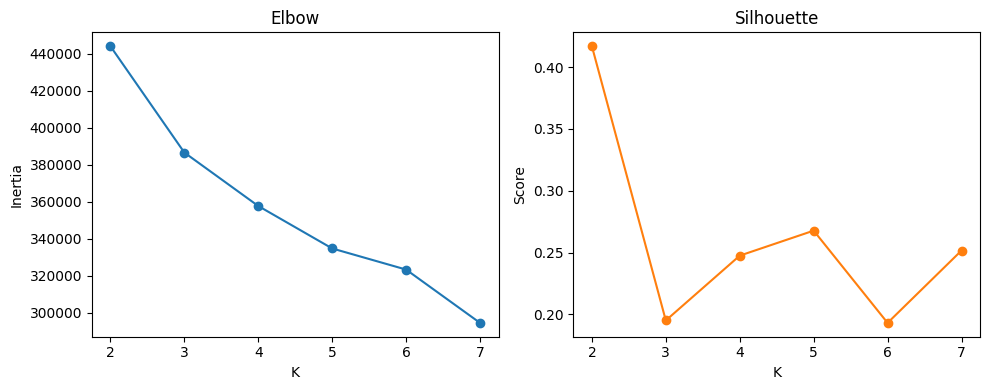

In [51]:

from sklearn.cluster import KMeans

# 1) Filtra sólo anomalías
anom = df[df['is_anomaly'] == 1].copy()

# 2) (Opcional) añade componentes cíclicos si quieres incluir estacionalidad
anom['month']     = anom['Fecha'].dt.month
anom['sin_month'] = np.sin(2*np.pi*(anom['month']-1)/12)
anom['cos_month'] = np.cos(2*np.pi*(anom['month']-1)/12)

anom['hour']      = anom['Fecha'].dt.hour
anom['sin_hour']  = np.sin(2*np.pi*anom['hour']/24)
anom['cos_hour']  = np.cos(2*np.pi*anom['hour']/24)

# 3) Elige tus variables de cluster
features = [
    'Temperatura','Presion','Volumen',
    # si quieres temporal,
    'sin_month','cos_month','sin_hour','cos_hour'
]
# Añade todas las columnas que empiecen con “C_CLIENTE”
features += [c for c in anom.columns if c.startswith('C_CLIENTE')]
X = anom[features].dropna()

# 4) Escala
scaler = StandardScaler().fit(X)
Xs     = scaler.transform(X)

# 5) Encuentra K óptimo (Elbow + Silhouette)
Ks = range(2,8)
inertias, silh = [], []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42).fit(Xs)
    inertias.append(km.inertia_)
    silh.append(silhouette_score(Xs, km.labels_))

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,4))
ax1.plot(Ks, inertias, 'o-'); ax1.set_title('Elbow'); ax1.set_xlabel('K'); ax1.set_ylabel('Inertia')
ax2.plot(Ks, silh,   'o-', color='C1'); ax2.set_title('Silhouette'); ax2.set_xlabel('K'); ax2.set_ylabel('Score')
plt.tight_layout(); plt.show()



Se combina el resultado de las dos metodologías graficadas para seleccionar 3 cluesters:

* En la gráfica de la izquierda (“Elbow”), la inercia cae muy fuerte al pasar de K=2 a K=3, y a partir de ahí la pendiente se suaviza notablemente. Ese codo en K≈3 nos dice que con tres clusters ya capturamos la mayor parte de la variabilidad de los datos; añadir más grupos solo aporta mejoras marginales.

En la gráfica de la derecha (“Silhouette”), el coeficiente oscila entre ~0.19 y ~0.27, alcanzando un pequeño pico en K=5, pero con K=3 seguimos manteniendo un valor razonable (≈0.20) y ganamos en simplicidad y estabilidad de los grupos.

Centroides de clusters de anomalías:
                        0             1             2
Temperatura  2.311323e+01  2.547317e+01  2.542233e+01
Presion      1.748277e+01  1.743530e+01  3.553166e+00
Volumen      1.694410e+01  4.053834e+01  1.264417e+02
sin_month    2.858069e-01 -8.937017e-02 -4.582834e-02
cos_month   -2.410916e-01  7.251031e-02 -3.082558e-01
sin_hour     5.221931e-02  5.030741e-02 -3.714928e-02
cos_hour     7.656613e-02  4.259942e-02 -1.981607e-02
C_CLIENTE1   0.000000e+00  0.000000e+00  0.000000e+00
C_CLIENTE10  1.084202e-18  1.671176e-03 -2.276825e-17
C_CLIENTE11 -1.387779e-15  2.387395e-04  8.733872e-01
C_CLIENTE12  1.057097e-18  3.978991e-04 -8.375462e-18
C_CLIENTE13  1.734723e-17  3.406016e-02  5.828671e-16
C_CLIENTE14  0.000000e+00  0.000000e+00  0.000000e+00
C_CLIENTE15  1.000000e+00  4.336809e-16  1.977585e-16
C_CLIENTE16  7.910339e-16  1.969601e-01  3.053113e-15
C_CLIENTE17  0.000000e+00  0.000000e+00  0.000000e+00
C_CLIENTE18  7.047314e-19  2.387395e-04 -6.09

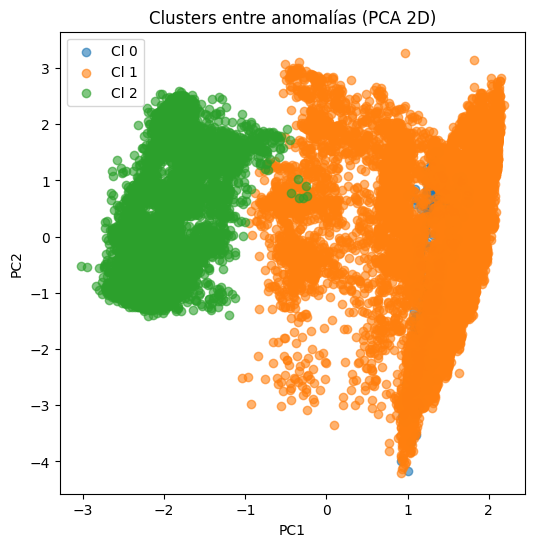

In [110]:
from sklearn.decomposition import PCA

# 6) Ajusta KMeans con el K elegido (p.ej. K=3)
K_opt = 3
km = KMeans(n_clusters=K_opt, random_state=42).fit(Xs)
anom['cluster_anom'] = km.labels_

# 7) Caracteriza cada cluster de anomalías
centroids = scaler.inverse_transform(km.cluster_centers_)
df_cent = pd.DataFrame(centroids, columns=features)
df_cent['cluster'] = range(K_opt)
print("Centroides de clusters de anomalías:")
print(df_cent.T)

size = anom['cluster_anom'].value_counts().sort_index()
print("\nTamaño de cada cluster:")
print(size)

# 8) (Opcional) Visualiza en 2D
proj = PCA(2, random_state=0).fit_transform(Xs)
anom['PC1'], anom['PC2'] = proj[:,0], proj[:,1]

plt.figure(figsize=(6,6))
for c in range(K_opt):
    sel = anom['cluster_anom']==c
    plt.scatter(anom.loc[sel,'PC1'], anom.loc[sel,'PC2'],
                label=f"Cl {c}", alpha=0.6)
plt.legend(); plt.title("Clusters entre anomalías (PCA 2D)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()

In [113]:
#Lista de clientes por cluster
clientes_por_cluster = {}
for c in range(K_opt):
    # Filtra el DataFrame de anomalías para el cluster c
    sub = anom[anom['cluster_anom'] == c]
    # Extrae los clientes únicos y ordénalos
    clientes = sorted(sub['Cliente'].unique())
    clientes_por_cluster[c] = clientes

# Muestra en pantalla
print("Clientes por cluster:")
for c, clist in clientes_por_cluster.items():
    print(f" Cluster {c} ({len(clist)} clientes): {clist}")

Clientes por cluster:
 Cluster 0 (1 clientes): ['CLIENTE7']
 Cluster 1 (14 clientes): ['CLIENTE10', 'CLIENTE12', 'CLIENTE13', 'CLIENTE14', 'CLIENTE15', 'CLIENTE17', 'CLIENTE18', 'CLIENTE19', 'CLIENTE2', 'CLIENTE20', 'CLIENTE4', 'CLIENTE5', 'CLIENTE7', 'CLIENTE8']
 Cluster 2 (3 clientes): ['CLIENTE11', 'CLIENTE2', 'CLIENTE3']


In [114]:
# Conteo de eventos por cliente en cada cluster
print("\nEventos por cliente en cada cluster:")
for c in range(K_opt):
    sub = anom[anom['cluster_anom'] == c]
    conteos = (
        sub
        .groupby('Cliente')
        .size()
        .sort_values(ascending=False)
        .rename("n_events")
    )
    print(f"\nCluster {c}:")
    print(conteos.to_string())


Eventos por cliente en cada cluster:

Cluster 0:
Cliente
CLIENTE7    340

Cluster 1:
Cliente
CLIENTE14    4340
CLIENTE19    2905
CLIENTE8     1366
CLIENTE15    1139
CLIENTE7     1109
CLIENTE20     617
CLIENTE5      428
CLIENTE18     283
CLIENTE17     176
CLIENTE13     148
CLIENTE10      25
CLIENTE2       24
CLIENTE4        5
CLIENTE12       1

Cluster 2:
Cliente
CLIENTE3     7237
CLIENTE11    1050
CLIENTE2        6


In [117]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42).fit(Xs)

# 2) Construye el DataFrame de cargas (loadings), usando la misma lista de features
loadings = pd.DataFrame(
    pca.components_,      # array shape (2, n_features)
    columns=features,     # nombres de las 27 columnas
    index=['PC1','PC2']   # filas = tus dos componentes
)

print(loadings)

     Temperatura   Presion   Volumen  sin_month  cos_month  sin_hour  \
PC1     0.042026  0.556587 -0.443829   0.042527   0.215313  0.034207   
PC2     0.625855 -0.061734  0.172476   0.365635   0.498498  0.095652   

     cos_hour    C_CLIENTE1  C_CLIENTE10  C_CLIENTE11  ...  C_CLIENTE19  \
PC1  0.038620 -4.336809e-19     0.006107    -0.511777  ...    -0.119669   
PC2  0.068562  1.734723e-18    -0.036605     0.048284  ...     0.015882   

       C_CLIENTE2  C_CLIENTE20  C_CLIENTE3  C_CLIENTE4    C_CLIENTE5  \
PC1 -6.018531e-36     0.046385    0.277853    0.091451  3.359066e-33   
PC2  0.000000e+00    -0.037358   -0.146864   -0.245368 -1.809053e-30   

     C_CLIENTE6  C_CLIENTE7  C_CLIENTE8  C_CLIENTE9  
PC1    0.045750    0.002904    0.253328    0.009733  
PC2    0.051143    0.002468    0.189689   -0.002596  

[2 rows x 27 columns]


Descripción de los Cluster: 
* Cluster 0 (340 registros, ≈1.6 % de todas las anomalías): este pequeño grupo agrupa exclusivamente a CLIENTE 7 y se caracteriza por valores de presión (~17.5 bar) y temperatura (~23 °C) casi idénticos al resto de operaciones, pero presenta volúmenes muy bajos (promedio ~17 m³ vs 40–120 m³ en los otros clusters). En el mapa PCA (azul), aparece muy concentrado sobre PC1≈–2.0, PC2≈+0.5, lo que indica que, aunque aquí la presión y temperatura no difieren sustancialmente, el volumen reducido es la señal principal de estas anomalías. Indica que la anomalía se puede presentar en caudales inusualmente bajos que mantienen presión y temperatura normales, posiblemente cortes parciales de flujo o cierres accidentales de válvulas.
* Cluster 1 (12 566 registros, ≈60 % de todas las anomalías): este es el cluster dominante, con anomalías de 14 clientes (CLIENTE 2, 4, 5, 8, 10, 12–15, 17–20). Sus centroides muestran presiones estables alrededor de 17.4 bar y temperaturas moderadas (~25.5–25.4 °C), pero volúmenes intermedios (~40 m³). En PCA (naranja), forma una nube ancha centrada en PC1≈+1.0, PC2≈0. Indica que muchas anomalías se deben a variaciones ligeras en volumen —ni tan bajo como Cluster 0 ni tan alto como Cluster 2— combinado con cambios sutiles de temperatura. Ligeras pero persistentes desviaciones en el caudal medio, sin fallos drásticos de presión o temperatura, que pueden señalar irregularidades de consumo o ajustes operativos fuera de rango habitual.
* Cluster 2 (8 293 registros, ≈38 % de todas las anomalías): comprende anomalías de 3 clientes (CLIENTE 3, 11, 2) y se caracteriza por volúmenes muy elevados (centroide ~126 m³), con presiones bajas (~3.55 bar) y temperaturas altas (~25.4 °C). En PCA (verde), queda ubicado hacia PC1≈–1.5, PC2≈+1.5, claramente separado. Aquí las anomalías proceden de picos de volumen que exceden con creces la operación normal, acompañados de presiones atípicamente bajas. Esto apunta a posibles situaciones de sobreconsumo o fugas masivas donde el caudal sube bruscamente y la presión cae. Picos bruscos de flujo que hacen caer la presión por debajo de lo normal, típicos de eventos de sobreconsumo, fugas importantes o rupturas parciales en la tubería.